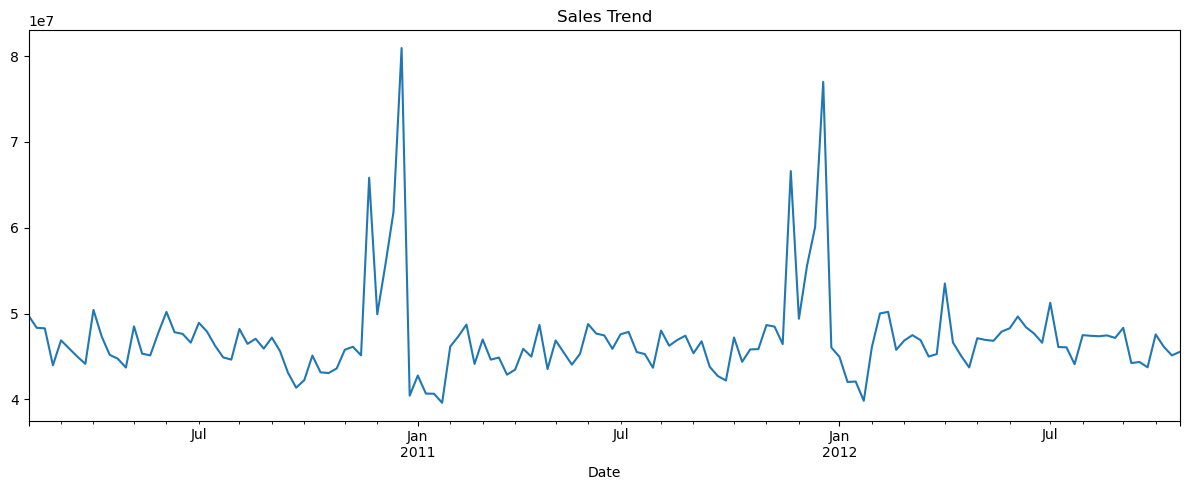

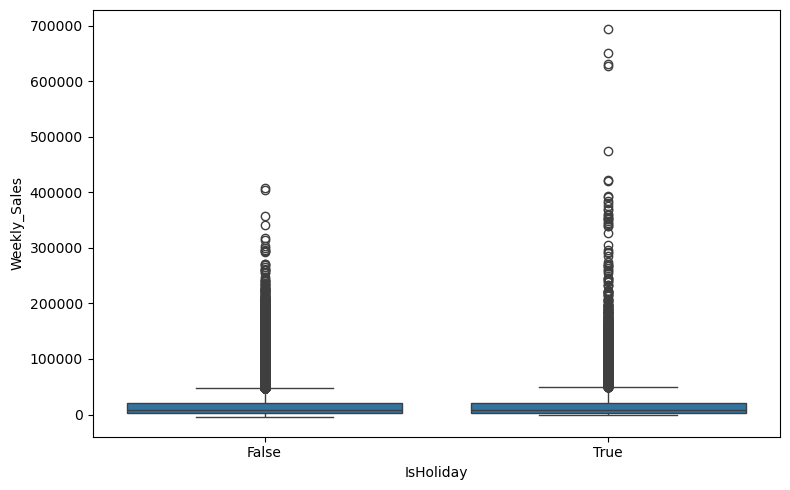

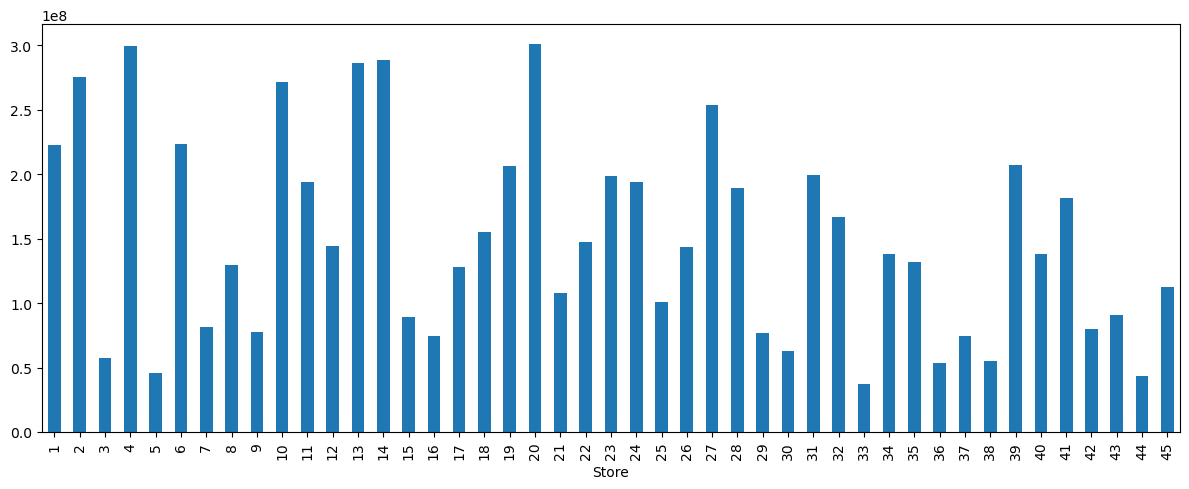

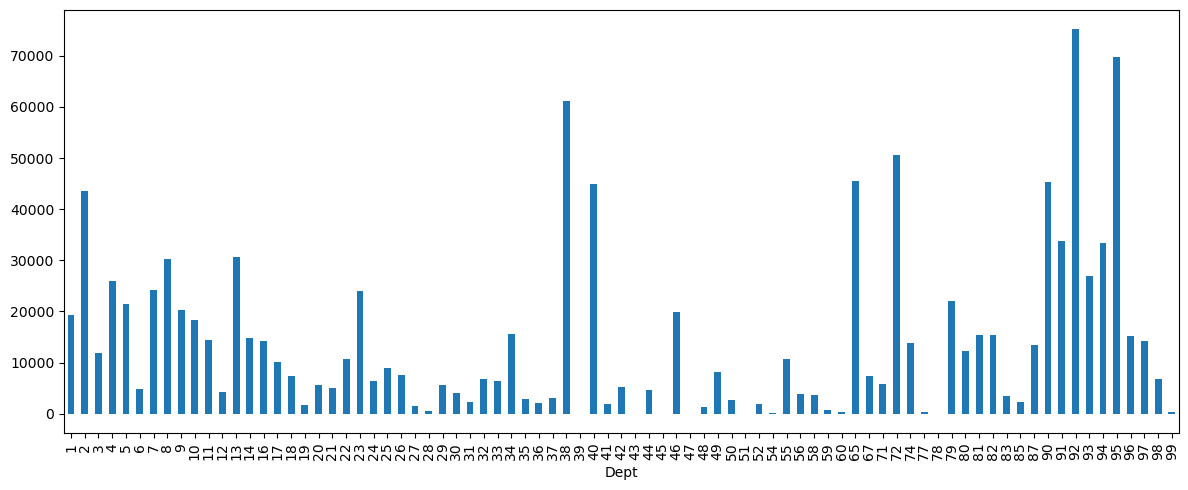

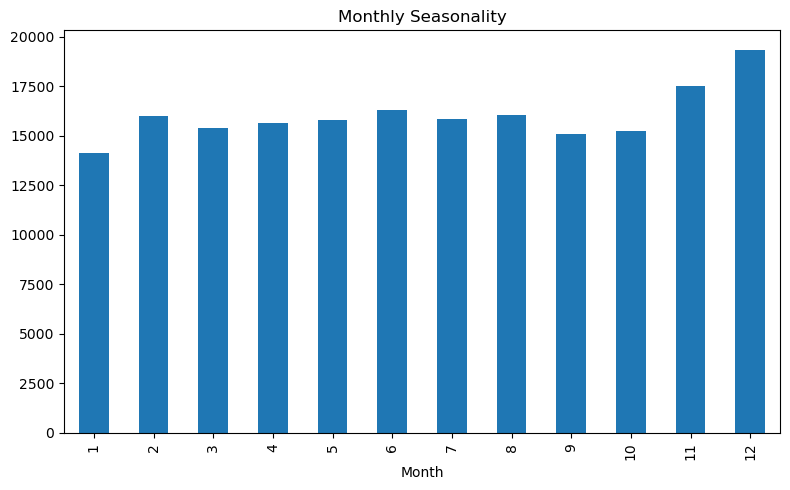

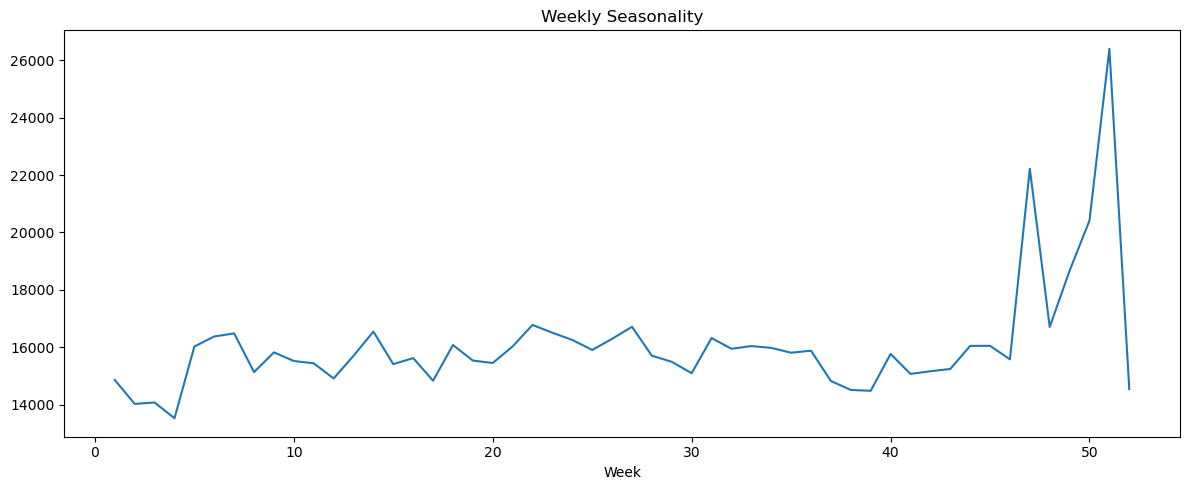

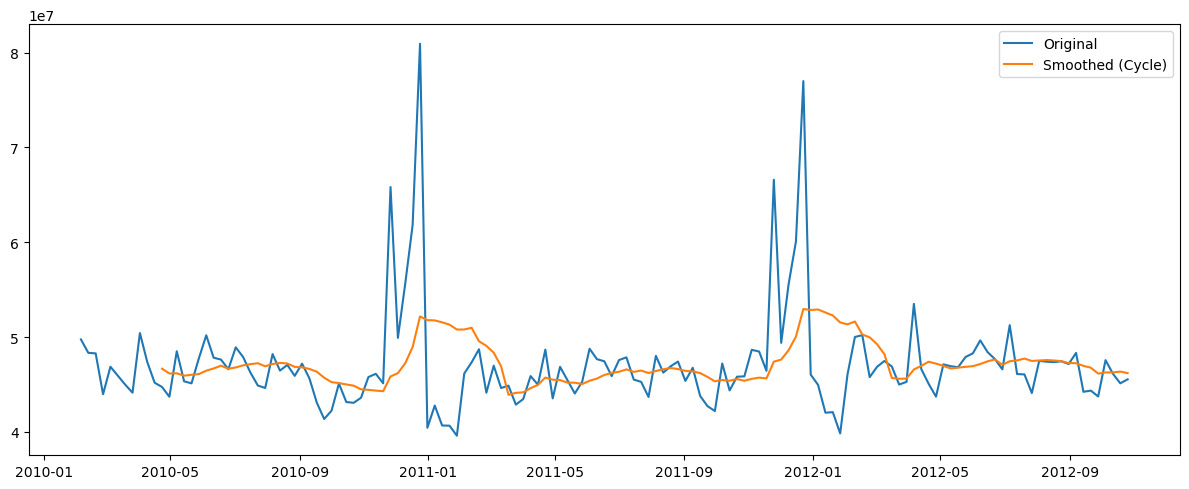

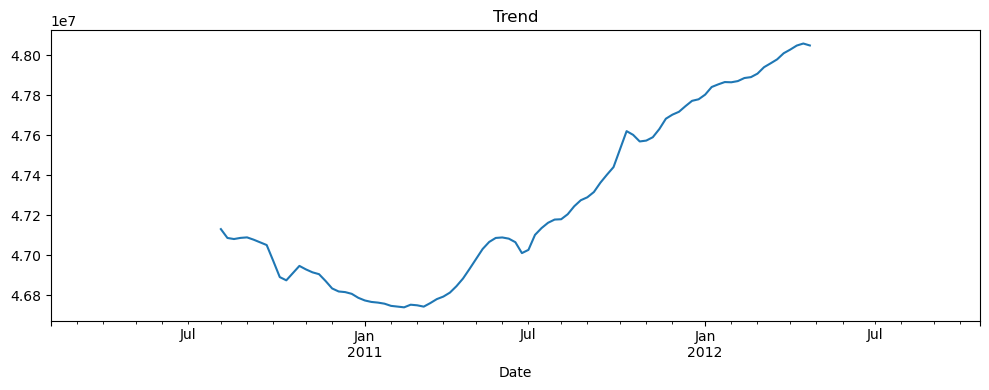

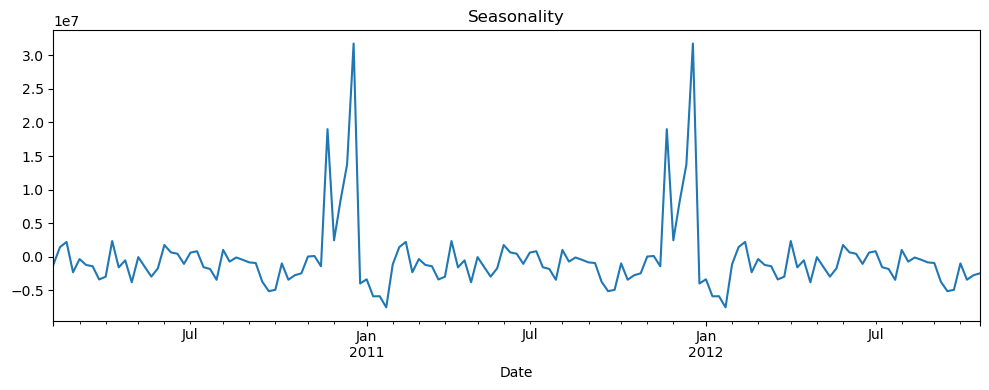

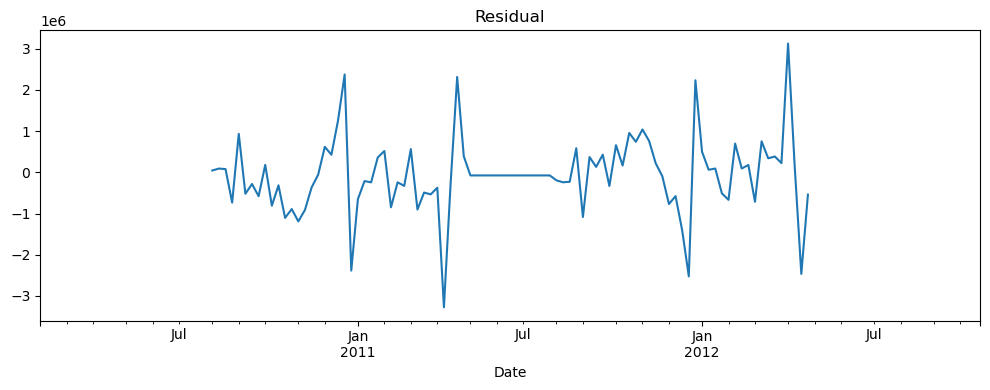

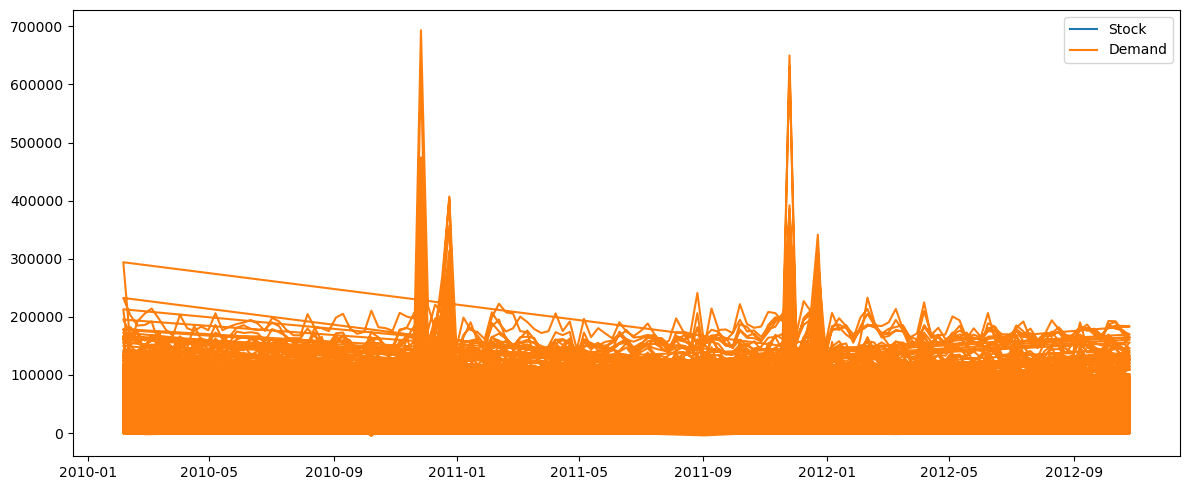

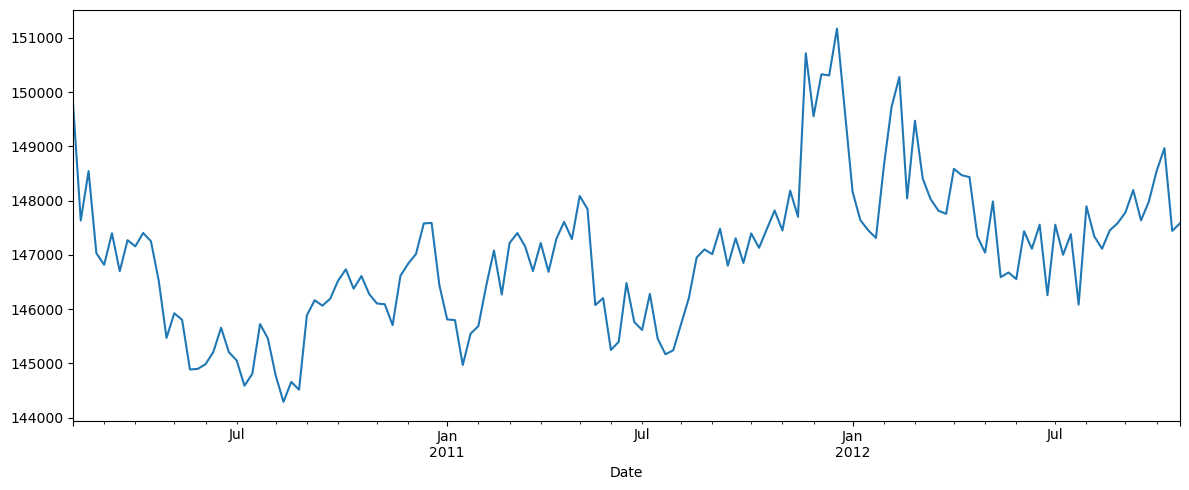

21:06:05 - cmdstanpy - INFO - Chain [1] start processing
21:06:05 - cmdstanpy - INFO - Chain [1] done processing


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step


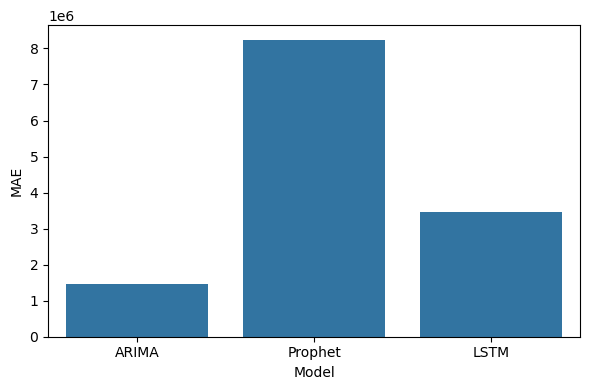

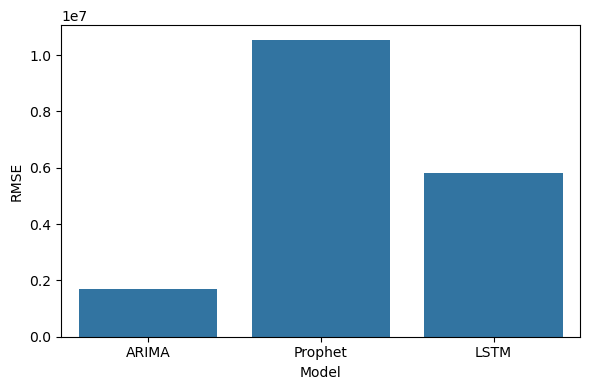

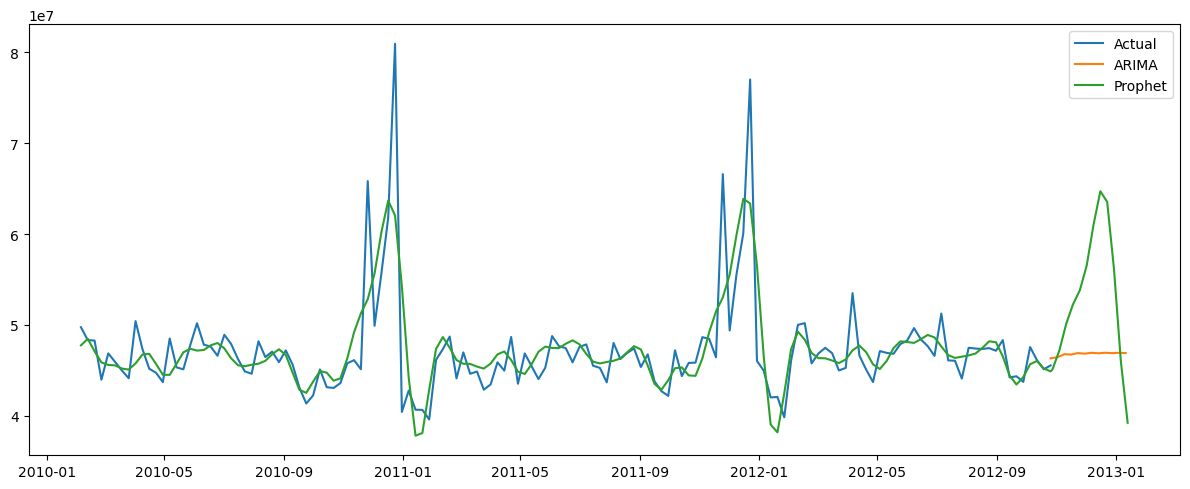

✅ COMPLETE — EDA + Seasonality + Cycle + Models + Graphs DONE


In [21]:
# ============================================================
# AI-DRIVEN RETAIL INVENTORY OPTIMIZATION SYSTEM (FINAL MASTER)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

# ===================== PATH SETUP =========================
base_path = r"C:\Users\CHUMKI\Downloads\Amity"
output_path = os.path.join(base_path, "output")
graph_path = os.path.join(output_path, "graphs")

os.makedirs(graph_path, exist_ok=True)

def save_and_show_plot(name):
    plt.tight_layout()
    plt.savefig(os.path.join(graph_path, f"{name}.png"), dpi=300)
    plt.show()
    plt.close()

# ===================== DATA LOAD =========================
train = pd.read_csv(os.path.join(base_path, "train.csv"))
features = pd.read_csv(os.path.join(base_path, "features.csv"))
stores = pd.read_csv(os.path.join(base_path, "stores.csv"))

train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

features = features.drop(columns=['IsHoliday'], errors='ignore')

df = train.merge(features, on=['Store','Date'], how='left')
df = df.merge(stores, on='Store', how='left')

df = df.sort_values(by=['Store','Dept','Date'])

markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# ===================== TIME SERIES =========================
ts = df.groupby('Date')['Weekly_Sales'].sum().sort_index()
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('W-FRI')

# ===================== EDA =========================

# Sales Trend
plt.figure(figsize=(12,5))
ts.plot(title="Sales Trend")
save_and_show_plot("sales_trend")

# Holiday Impact
plt.figure(figsize=(8,5))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
save_and_show_plot("holiday_impact")

# Store Sales
plt.figure(figsize=(12,5))
df.groupby('Store')['Weekly_Sales'].sum().plot(kind='bar')
save_and_show_plot("store_sales")

# Dept Demand
plt.figure(figsize=(12,5))
df.groupby('Dept')['Weekly_Sales'].mean().plot(kind='bar')
save_and_show_plot("dept_demand")

# ===================== SEASONALITY =========================

# Monthly Seasonality
plt.figure(figsize=(8,5))
df.groupby('Month')['Weekly_Sales'].mean().plot(kind='bar')
plt.title("Monthly Seasonality")
save_and_show_plot("monthly_seasonality")

# Weekly Seasonality
plt.figure(figsize=(12,5))
df.groupby('Week')['Weekly_Sales'].mean().plot()
plt.title("Weekly Seasonality")
save_and_show_plot("weekly_seasonality")

# ===================== CYCLE =========================

ts_smooth = ts.rolling(12).mean()

plt.figure(figsize=(12,5))
plt.plot(ts, label='Original')
plt.plot(ts_smooth, label='Smoothed (Cycle)')
plt.legend()
save_and_show_plot("cycle_trend")

# ===================== DECOMPOSITION =========================

decomp = seasonal_decompose(ts, model='additive')

plt.figure(figsize=(10,4))
decomp.trend.plot(title="Trend")
save_and_show_plot("trend_component")

plt.figure(figsize=(10,4))
decomp.seasonal.plot(title="Seasonality")
save_and_show_plot("seasonal_component")

plt.figure(figsize=(10,4))
decomp.resid.plot(title="Residual")
save_and_show_plot("residual_component")

# ===================== INVENTORY =========================

INITIAL_STOCK = 50000.0
LEAD_TIME = 2
SAFETY_STOCK = 10000

df['Demand'] = df['Weekly_Sales'].astype(float)

stock = [INITIAL_STOCK]
for i in range(1, len(df)):
    new_stock = max(stock[-1] - df.iloc[i]['Demand'], 0)
    stock.append(new_stock)

df['Stock'] = stock

df['Rolling_Demand'] = df['Demand'].rolling(4).mean().bfill()
df['Reorder_Point'] = df['Rolling_Demand'] * LEAD_TIME + SAFETY_STOCK

df['Order'] = np.where(df['Stock'] < df['Reorder_Point'], 20000, 0)
df['Replenishment'] = df['Order'].shift(LEAD_TIME).fillna(0)

df['Stockout'] = df['Demand'] > df['Stock']

# Stock vs Demand
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Stock'], label="Stock")
plt.plot(df['Date'], df['Demand'], label="Demand")
plt.legend()
save_and_show_plot("stock_vs_demand")

# ===================== COST =========================

df['Holding_Cost'] = df['Stock'] * 0.05
df['Stockout_Cost'] = df['Stockout'].astype(int) * 50
df['Total_Cost'] = df['Holding_Cost'] + df['Stockout_Cost']

plt.figure(figsize=(12,5))
df.groupby('Date')['Total_Cost'].sum().plot()
save_and_show_plot("cost_trend")

# ===================== FORECASTING =========================

model_arima = ARIMA(ts, order=(2,1,2)).fit()
forecast_arima = model_arima.forecast(steps=12)

prophet_df = ts.reset_index()
prophet_df.columns = ['ds','y']

model_prophet = Prophet()
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=12, freq='W')
forecast_prophet = model_prophet.predict(future)

# LSTM
data = ts.values.reshape(-1,1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

X, y = [], []
for i in range(10, len(data_scaled)):
    X.append(data_scaled[i-10:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)

model_lstm = Sequential([
    Input(shape=(X.shape[1],1)),
    LSTM(50),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X, y, epochs=5, verbose=0)

pred_lstm = scaler.inverse_transform(model_lstm.predict(X))

# ===================== MODEL COMPARISON =========================

def evaluate(actual, pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred))
    }

results = []
results.append(evaluate(ts[-12:], forecast_arima, "ARIMA"))
results.append(evaluate(ts[-12:], forecast_prophet.tail(12)['yhat'], "Prophet"))
results.append(evaluate(ts[-len(pred_lstm):], pred_lstm.flatten(), "LSTM"))

results_df = pd.DataFrame(results)

plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='MAE', data=results_df)
save_and_show_plot("model_mae")

plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='RMSE', data=results_df)
save_and_show_plot("model_rmse")

# ===================== FORECAST GRAPH =========================

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label="Actual")

future_dates = pd.date_range(start=ts.index[-1], periods=12, freq='W-FRI')
plt.plot(future_dates, forecast_arima, label="ARIMA")
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label="Prophet")

plt.legend()
save_and_show_plot("forecast_comparison")

# ===================== RL =========================

demand_series = ts.values

class InventoryEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.stock = 50000.0
        self.t = 0
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=100000, shape=(1,), dtype=np.float32)

    def step(self, action):
        demand = demand_series[self.t % len(demand_series)]
        order = [0,10000,20000][action]
        self.stock = max(self.stock - demand + order, 0)
        reward = -abs(self.stock - 30000)
        self.t += 1
        return np.array([self.stock], dtype=np.float32), reward, False, False, {}

    def reset(self, seed=None, options=None):
        self.stock = 50000.0
        self.t = 0
        return np.array([self.stock], dtype=np.float32), {}

env = InventoryEnv()
model = PPO("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=3000)

# ===================== SAVE =========================

df.to_csv(os.path.join(output_path, "final_inventory_output.csv"), index=False)
forecast_prophet.to_csv(os.path.join(output_path, "forecast_output.csv"), index=False)

print("✅ COMPLETE — EDA + Seasonality + Cycle + Models + Graphs DONE")

In [25]:
# ===================== SAVE MODEL PERFORMANCE =====================

results_df.to_csv(os.path.join(output_path, "model_performance.csv"), index=False)
print("Model performance saved!")

Model performance saved!
